In [169]:
import pandas as pd


pd.set_option("display.max_rows", 15)
pd.options.display.float_format = '{:,.0f}'.format

%matplotlib inline

AVTOMOBILI = pd.read_csv("podatki/avtomobili_csv")

In [170]:
stolpci = ["znamka", "model", "leto"] + [c for c in AVTOMOBILI.columns if c not in ["znamka", "model", "leto", "link"]] + ["link"]
AVTOMOBILI = AVTOMOBILI[stolpci]

AVTOMOBILI = AVTOMOBILI.sort_values(
    ["znamka", "leto", "doseg_[km]"],
    ascending=[True, True, False]
)

AVTOMOBILI

,znamka,model,leto,doseg_[km],poraba_[kWh/100km],kapaciteta_[kWh],cas_polnjenja[min/100km],pospesek(0-100km/h)_[s],cena_[EUR],drzava,link
1172,Abarth,500e Scorpionissima,2023,225,17,37,17,7,"43,000",Italija,https://bestev4me.eu/ev-catalog/1790/abarth-50...
1174,Abarth,500e Hatchback,2023,225,17,37,17,7,"37,990",Italija,https://bestev4me.eu/ev-catalog/1903/abarth-50...
1175,Abarth,500e Convertible,2023,225,17,37,17,7,"40,990",Italija,https://bestev4me.eu/ev-catalog/1904/abarth-50...
1020,Abarth,600e Turismo,2024,280,18,51,15,6,"41,990",Italija,https://bestev4me.eu/ev-catalog/3056/abarth-60...
1021,Abarth,600e Scorpionissima,2024,280,18,51,15,6,"48,990",Italija,https://bestev4me.eu/ev-catalog/3057/abarth-60...
...,...,...,...,...,...,...,...,...,...,...,...
812,Zeekr,X Privilege AWD,2026,350,19,65,11,4,"47,990",Kitajska,https://bestev4me.eu/ev-catalog/3586/zeekr-x-p...
931,Zeekr,X Long Range RWD,2026,320,18,59,9,6,"42,990",Kitajska,https://bestev4me.eu/ev-catalog/3585/zeekr-x-l...
1092,Zeekr,X Core RWD,2026,260,18,47,18,6,"37,990",Kitajska,https://bestev4me.eu/ev-catalog/3584/zeekr-x-c...
1268,e.GO,e.wave X,2022,150,18,27,120,12,"24,990",Nemčija,https://bestev4me.eu/ev-catalog/1896/ego-ewave...


In [171]:
manjkajoce_vrednosti = AVTOMOBILI.isna().sum()
manjkajoce_vrednosti

znamka                       0
model                        0
leto                         0
doseg_[km]                   0
poraba_[kWh/100km]           0
kapaciteta_[kWh]             0
cas_polnjenja[min/100km]     0
pospesek(0-100km/h)_[s]      0
cena_[EUR]                  74
drzava                       0
link                         0
dtype: int64

In [172]:
top10_doseg = AVTOMOBILI[["znamka", "model", "leto", "doseg_[km]"]].copy()
top10_doseg = top10_doseg.sort_values("doseg_[km]", ascending=False).head(10)
top10_doseg

,znamka,model,leto,doseg_[km]
0,Mercedes-Benz,EQS 450+,2026,720
1,Lucid,Air Grand Touring,2024,720
2,BMW,i3 50 xDrive,2026,715
4,Lucid,Air Dream Edition R,2022,685
3,Mercedes-Benz,EQS 450+,2024,685
5,Mercedes-Benz,EQS 500 4MATIC,2026,680
9,BMW,iX5 60 xDrive,2026,670
7,Lucid,Air Dream Edition P,2022,670
6,Mercedes-Benz,EQS 580 4MATIC,2026,670
8,Mercedes-Benz,EQS 400,2026,670


In [173]:
cene_podtabela = AVTOMOBILI[["znamka", "model", "leto", "cena_[EUR]", "drzava"]].copy()

top10_najcenejsa = cene_podtabela.sort_values("cena_[EUR]", ascending=True).head(10)
top10_najcenejsa

,znamka,model,leto,cena_[EUR],drzava
1257,Dacia,Spring Electric 45,2024,"16,900",Romunija
1258,Dacia,Spring Electric 70,2025,"18,700",Romunija
1178,Leapmotor,T03,2024,"18,900",Kitajska
1264,Dacia,Spring Electric 65,2024,"18,900",Romunija
1296,Smart,EQ forfour,2020,"19,120",Nemčija
1265,Dacia,Spring Electric 100,2025,"19,700",Romunija
1227,Renault,Twingo E-Tech 27.5 kWh,2025,"19,990",Francija
1245,Citroen,ë-C3 Urban Range 30 kWh,2025,"19,990",Francija
1262,Dacia,Spring Electric,2021,"20,490",Romunija
1261,Dacia,Spring Electric,2021,"20,490",Romunija


In [174]:
top10_najdrazja = cene_podtabela.sort_values("cena_[EUR]", ascending=False).head(10)
top10_najdrazja


,znamka,model,leto,cena_[EUR],drzava
37,Ferrari,Luce,2026,"550,000",Italija
132,Rolls-Royce,Spectre Series II,2026,"395,060",Združeno kraljestvo
288,Rolls-Royce,Spectre,2023,"379,015",Združeno kraljestvo
65,Lightyear,0,2022,"297,500",Nizozemska
18,Lucid,Air Sapphire,2025,"250,000",ZDA
255,Porsche,Taycan Turbo GT Weissach,2024,"240,000",Nemčija
256,Porsche,Taycan Turbo GT,2024,"240,000",Nemčija
7,Lucid,Air Dream Edition P,2022,"218,000",ZDA
4,Lucid,Air Dream Edition R,2022,"218,000",ZDA
219,Porsche,Taycan Turbo S Cross Turismo,2024,"211,300",Nemčija


In [175]:
povprecne_cene_po_drzavi = AVTOMOBILI.groupby("drzava")["cena_[EUR]"].agg(["mean", "count"]).round(2)
povprecne_cene_po_drzavi = povprecne_cene_po_drzavi.sort_values("mean", ascending= False)
povprecne_cene_po_drzavi

,mean,count
drzava,,
Nizozemska,"297,500",1
Združeno kraljestvo,"99,376",29
Italija,"78,830",23
Nemčija,"76,298",454
ZDA,"75,910",153
...,...,...
Španija,"43,935",21
Francija,"43,648",118
Turčija,"41,302",5


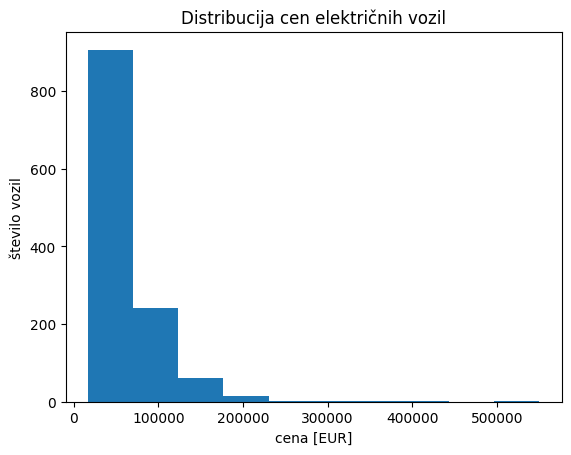

In [200]:


cene = AVTOMOBILI["cena_[EUR]"].dropna().plot.hist()

cene.set_xlabel("cena [EUR]")
cene.set_ylabel("število vozil")
cene.set_title("Distribucija cen električnih vozil");



In [176]:
podtabela_vrednost = AVTOMOBILI[["znamka", "model", "leto", "doseg_[km]", "cena_[EUR]"]].copy()

podtabela_vrednost["cena_na_km"] = (podtabela_vrednost["cena_[EUR]"] / podtabela_vrednost["doseg_[km]"]).round(2)

top10_vrednost = podtabela_vrednost.sort_values("cena_na_km", ascending=True).head(10)
top10_vrednost

,znamka,model,leto,doseg_[km],cena_[EUR],cena_na_km
39,Tesla,Model 3 Long Range RWD,2025,580,"45,970",79
36,Tesla,Model 3 Premium RWD,2025,580,"45,970",79
67,Tesla,Model 3 Long Range RWD,2024,550,"44,990",82
191,TOGG,T10F Long Range RWD,2025,490,"40,118",82
667,Leapmotor,B05 67.1 kWh,2026,380,"31,900",84
1178,Leapmotor,T03,2024,225,"18,900",84
377,Tesla,Model 3 RWD,2025,450,"37,970",84
978,Hyundai,INSTER Long Range,2024,300,"25,400",85
902,GAC,AION UT 60 kWh,2026,330,"28,000",85
145,Kia,EV4 Hatchback 81.4 kWh,2025,505,"43,240",86


In [177]:
podtabela_pospesek = AVTOMOBILI[["znamka", "model", "leto", "pospesek(0-100km/h)_[s]", "cena_[EUR]"]].copy()

filter_sportna = podtabela_pospesek["pospesek(0-100km/h)_[s]"] < 4
sportna_vozila = podtabela_pospesek[filter_sportna]

print(len(sportna_vozila))

po_znamki = sportna_vozila.groupby("znamka").size().sort_values(ascending=False)
po_znamki

136


znamka
Porsche          30
Tesla            27
BMW              10
Mercedes-Benz    10
Lucid             9
                 ..
Ferrari           1
Maserati          1
Kia               1
Hongqi            1
XPENG             1
Length: 23, dtype: int64

<Axes: title={'center': 'Znamke z največ modeli'}, xlabel='znamka'>

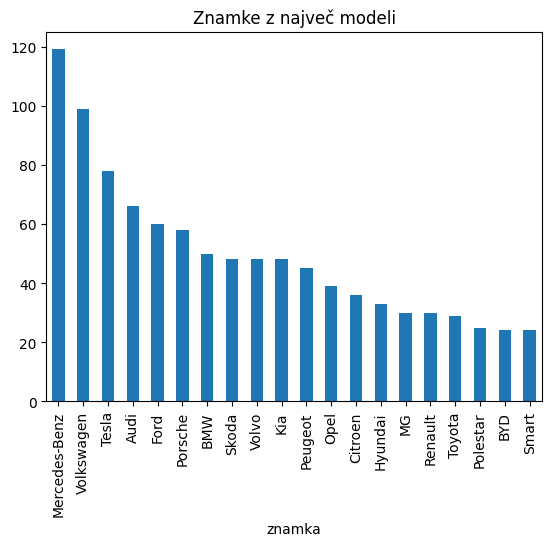

In [178]:
stevilo_modelov = AVTOMOBILI.groupby("znamka").size().sort_values(ascending=False)
top20 = stevilo_modelov.head(20)
top20.plot.bar(title = "Znamke z največ modeli")

In [179]:
napredek_po_letih = AVTOMOBILI.groupby("leto")[ ["doseg_[km]", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]", "poraba_[kWh/100km]"]].mean().round(2)
napredek_po_letih["st_avtov"] = AVTOMOBILI.groupby("leto").size()
zanesljiva_leta = napredek_po_letih[napredek_po_letih["st_avtov"] >= 10]
zanesljiva_leta

,doseg_[km],kapaciteta_[kWh],cas_polnjenja[min/100km],poraba_[kWh/100km],st_avtov
leto,,,,,
2015,292,56,34,19,10
2016,314,62,19,19,20
2017,201,37,89,18,16
2018,224,39,38,18,13
2019,349,68,38,20,26
2020,285,58,21,20,81
2021,325,64,16,20,113
2022,392,75,14,19,148
2023,403,76,12,19,175


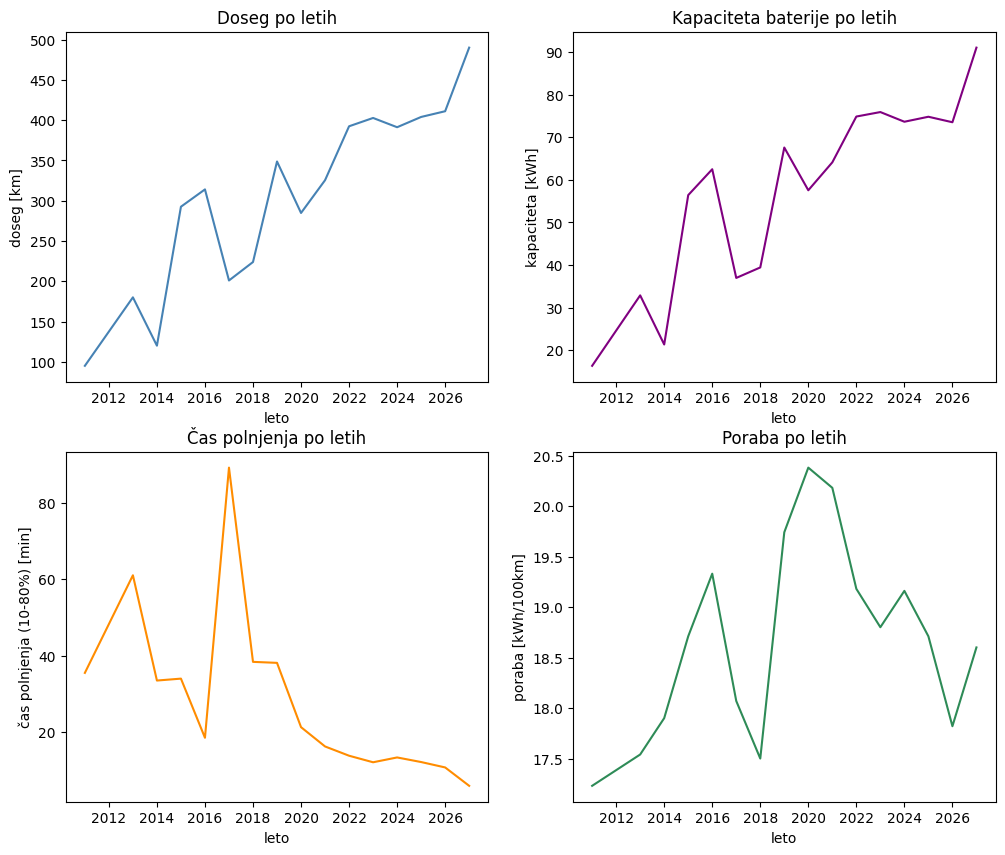

In [180]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

napredek_po_letih["doseg_[km]"].plot(ax=axes[0, 0], color="steelblue", ylabel = "doseg [km]")
axes[0, 0].set_title("Doseg po letih")

napredek_po_letih["kapaciteta_[kWh]"].plot(ax=axes[0, 1], color="purple", ylabel="kapaciteta [kWh]")
axes[0, 1].set_title("Kapaciteta baterije po letih")

napredek_po_letih["cas_polnjenja[min/100km]"].plot(ax=axes[1, 0], color="darkorange", ylabel = "čas polnjenja (10-80%) [min]")
axes[1, 0].set_title("Čas polnjenja po letih")

napredek_po_letih["poraba_[kWh/100km]"].plot(ax=axes[1, 1],color="seagreen", ylabel = "poraba [kWh/100km]" )
axes[1, 1].set_title("Poraba po letih");



In [181]:
avtomobili_2018 = AVTOMOBILI[AVTOMOBILI["leto"] == 2018]
avtomobili_2018[["znamka", "model", "doseg_[km]", "poraba_[kWh/100km]", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]"]]


,znamka,model,doseg_[km],poraba_[kWh/100km],kapaciteta_[kWh],cas_polnjenja[min/100km]
1144,BMW,i3 120 Ah,235,16,38,23
1161,BMW,i3s 120 Ah,230,16,38,24
1119,Hyundai,Kona Electric 39 kWh,245,16,39,29
646,Jaguar,I-Pace EV400,380,22,85,18
672,Kia,e-Niro 64 kWh,375,17,64,18
1142,Nissan,LEAF 40 kWh,235,17,39,27
1247,Nissan,e-NV200 Evalia,170,22,37,36
1095,Renault,Zoe R90,255,16,41,55
1109,Renault,Zoe R110,250,16,41,55
1120,Renault,Zoe Q90,245,17,41,34


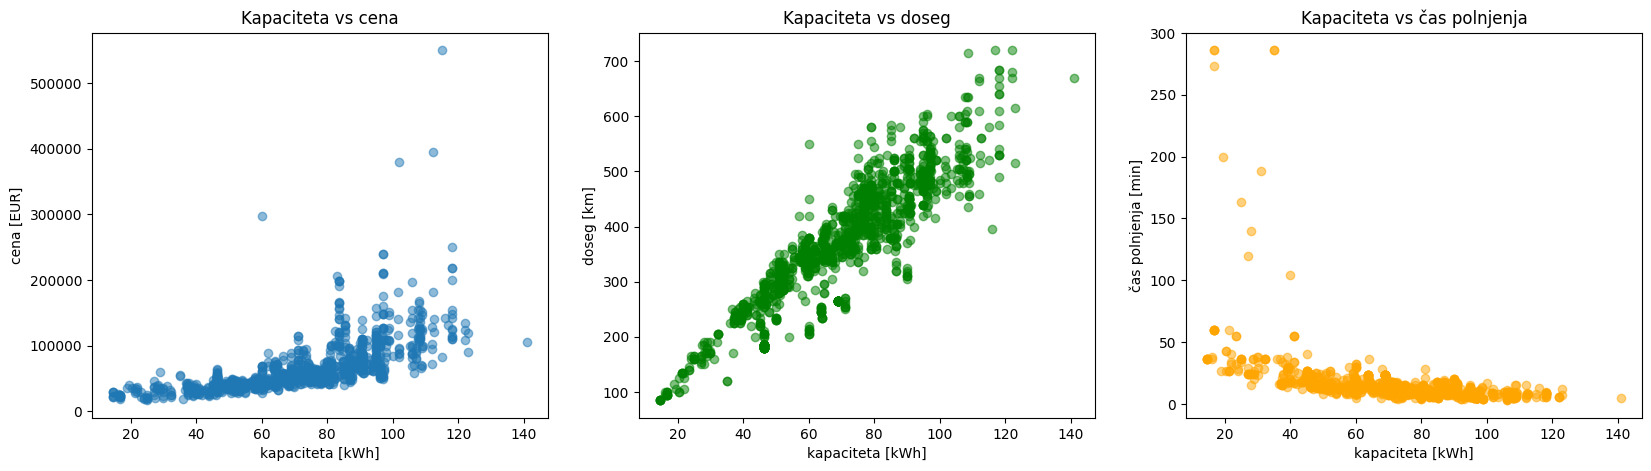

In [182]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["cena_[EUR]"], alpha=0.5)
axes[0].set_xlabel("kapaciteta [kWh]")
axes[0].set_ylabel("cena [EUR]")
axes[0].set_title("Kapaciteta vs cena")

axes[1].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["doseg_[km]"], alpha=0.5, color="green")
axes[1].set_xlabel("kapaciteta [kWh]")
axes[1].set_ylabel("doseg [km]")
axes[1].set_title("Kapaciteta vs doseg")

axes[2].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["cas_polnjenja[min/100km]"], alpha=0.5, color="orange")
axes[2].set_xlabel("kapaciteta [kWh]")
axes[2].set_ylabel("čas polnjenja [min]")
axes[2].set_title("Kapaciteta vs čas polnjenja");



In [209]:
osamelci = AVTOMOBILI[
    (AVTOMOBILI["kapaciteta_[kWh]"] < 40) &
    (AVTOMOBILI["cas_polnjenja[min/100km]"] > 100)
]

osamelci[["znamka", "model", "leto", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]", "link"]].sort_values(
    "cas_polnjenja[min/100km]", ascending=False
)

,znamka,model,leto,kapaciteta_[kWh],cas_polnjenja[min/100km],link
1280,Mercedes-Benz,eVito Tourer Extra-Long 41 kWh,2019,35,286,https://bestev4me.eu/ev-catalog/1614/mercedes-...
1279,Mercedes-Benz,eVito Tourer Long 41 kWh,2019,35,286,https://bestev4me.eu/ev-catalog/1613/mercedes-...
1292,Smart,ForTwo Cabrio Electric Drive,2017,17,286,https://bestev4me.eu/ev-catalog/1099/smart-for...
1291,Smart,ForFour Electric Drive,2017,17,286,https://bestev4me.eu/ev-catalog/1091/smart-for...
1285,Smart,ForTwo Electric Drive,2017,17,273,https://bestev4me.eu/ev-catalog/1090/smart-for...
1282,Ford,Focus Electric,2013,20,200,https://bestev4me.eu/ev-catalog/1010/ford-focu...
1259,Renault,Kangoo Maxi ZE 33,2017,31,188,https://bestev4me.eu/ev-catalog/1101/renault-k...
1257,Dacia,Spring Electric 45,2024,25,163,https://bestev4me.eu/ev-catalog/2126/dacia-spr...
1267,Mercedes-Benz,B 250e,2015,28,140,https://bestev4me.eu/ev-catalog/1013/mercedes-...
1268,e.GO,e.wave X,2022,27,120,https://bestev4me.eu/ev-catalog/1896/ego-ewave...
